In [1]:
#Imports and directory
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [2]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [3]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
#add a Date column
all_data['date'] = pd.to_datetime(all_data[['Year', 'Month', 'Day', 'Hour']])
all_data=all_data[all_data['Year']>=2019]

In [4]:
days = {
    "Summer Weekday": "2023-06-15",   # already used
    "Winter Weekday": "2023-01-15",   # already used
    "Fall Weekend":   "2023-10-14",   # Saturday
    "Spring Weekend": "2023-04-16"    # Sunday
}


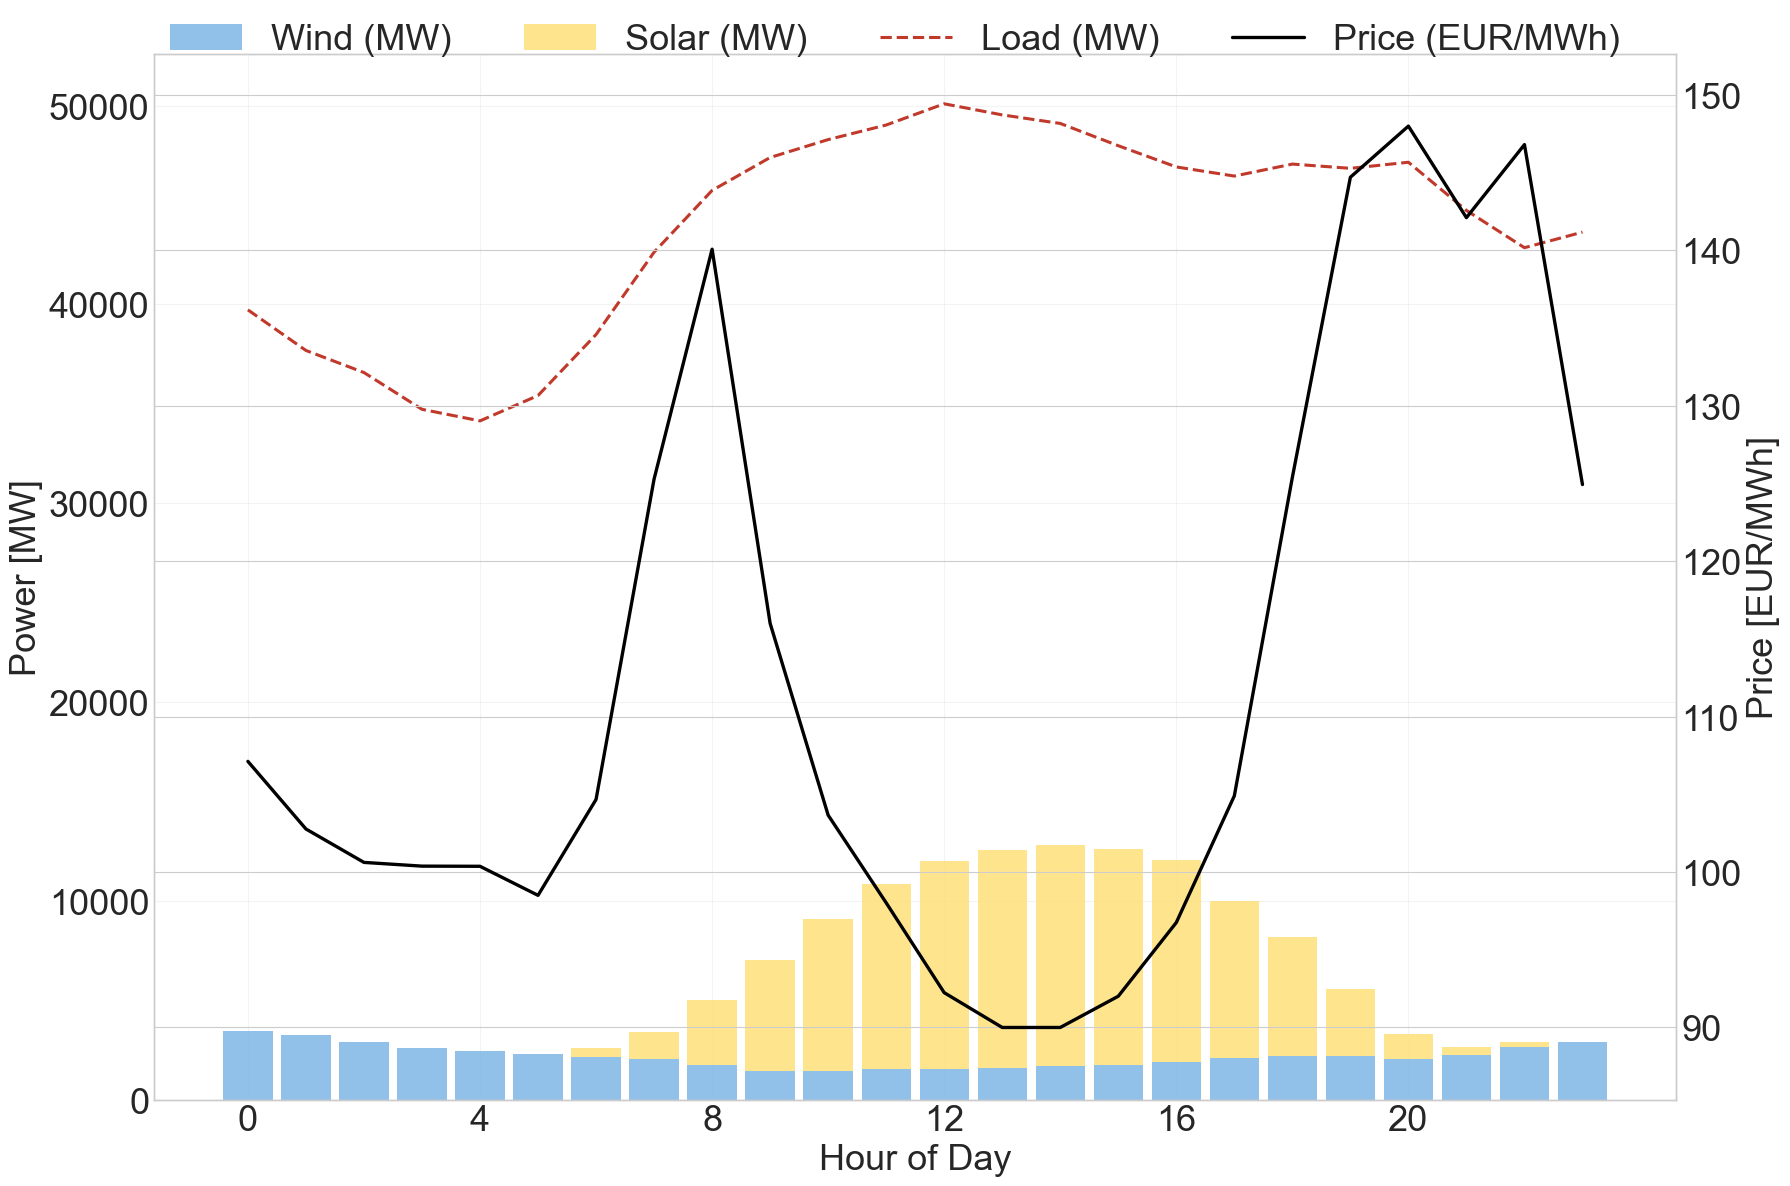

In [5]:


plt.style.use("seaborn-v0_8-whitegrid")  # clean scientific style

# Define the days to compare
days = {
    "Summer Weekday (15 Jun 2023)": "2023-06-15",
                # "Winter Weekday (11 Jan 2023)": "2023-01-11",
                # "Fall Weekend (14 Oct 2023)":   "2023-10-14",
                # "Spring Weekend (16 Apr 2023)": "2023-04-16"
}

fig, axes = plt.subplots(1, 1, figsize=(18, 12), sharex=True)
axes = [axes]  # Make it iterable

all_handles = []
all_labels = []

# Precompute global nice limits for price axis
# (so all 4 days use the same scale → visually comparable)
sample_days = [pd.to_datetime(d).date() for d in days.values()]
sample_df = all_data[all_data['date'].dt.date.isin(sample_days)]

price_min = np.nanmin(sample_df["EUR/MWh"])
price_max = np.nanmax(sample_df["EUR/MWh"])
price_padding = 0.08 * (price_max - price_min)

# main plotting loop
for ax, (title, chosen_day) in zip(axes, days.items()):

    # subset for that day
    day_df = all_data[all_data['date'].dt.date == pd.to_datetime(chosen_day).date()]
    hours = day_df['Hour']

    # --------------------------
    # STACKED RENEWABLE BARS
    # --------------------------
    h1 = ax.bar(hours, day_df['Wind_RT'],
                color='#7eb6e6', alpha=0.85, width=0.85,
                label='Wind_RT')

    h2 = ax.bar(hours, day_df['Solar_RT'],
                bottom=day_df['Wind_RT'],
                color='#ffe07a', alpha=0.85, width=0.85,
                label='Solar_RT')

    # --------------------------
    # LOAD CURVE
    # --------------------------
    h3, = ax.plot(hours, day_df['Load_RT'],
                  color='#c0392b', linewidth=2.2, linestyle='--',
                  label='Load_RT')

    # --------------------------
    # PRICE CURVE (right axis)
    # --------------------------
    ax2 = ax.twinx()
    h4, = ax2.plot(hours, day_df['EUR/MWh'],
                   color='black', linewidth=2.4,
                   label='Price')

    # enforce consistent right-axis limits
    ax2.set_ylim(price_min - price_padding, price_max + price_padding)

    # collect legend once
    if not all_labels:
        all_handles = [h1, h2, h3, h4]
        all_labels = ["Wind (MW)", "Solar (MW)", "Load (MW)", "Price (EUR/MWh)"]

    # aesthetic formatting

    ax.set_ylabel("Power [MW]", fontsize=26)
    ax2.set_ylabel("Price [EUR/MWh]", fontsize=26)
    
    ax.set_xticks(range(0, 24, 4))
    ax.tick_params(axis='both', labelsize=26)
    ax2.tick_params(axis='y', labelsize=26)

    # clean grid
    ax.grid(True, alpha=0.22)

# common X-label on bottom row
for ax in axes[-2:]:
    ax.set_xlabel("Hour of Day", fontsize=26)

# unified legend above plots
fig.legend(all_handles, all_labels,
           loc='upper center', ncol=4, fontsize=26,
           frameon=False, bbox_to_anchor=(0.5, 1.0))



plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


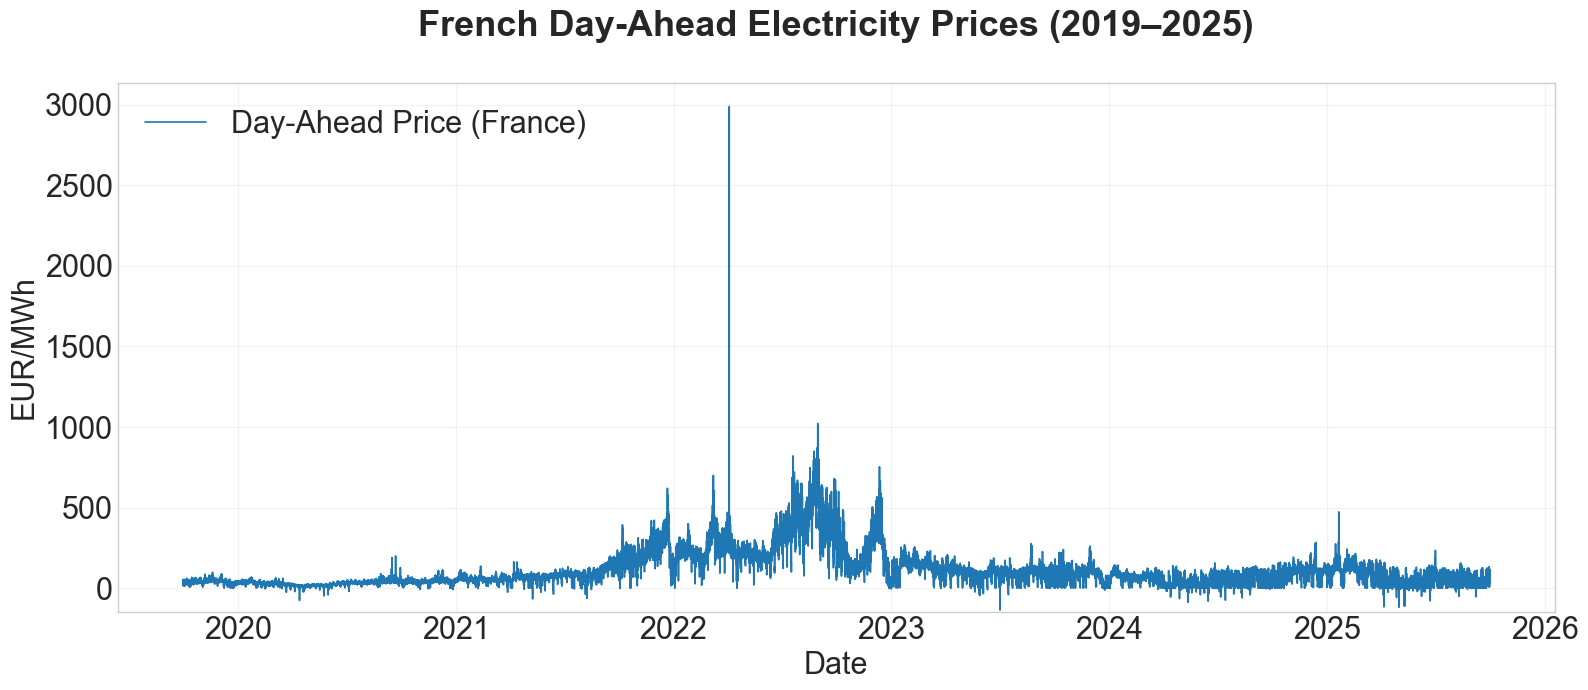

In [6]:


plt.style.use("seaborn-v0_8-whitegrid")

dates = all_data['date']
prices = all_data['EUR/MWh']

fig, ax = plt.subplots(figsize=(16, 7))

# =====================================================================
# MAIN PRICE LINE
# =====================================================================
ax.plot(dates, prices,
        color='#1f77b4', linewidth=1.2,
        label="Day-Ahead Price (France)")

# =====================================================================
# CRISIS PERIODS WITH IMPROVED VISUAL QUALITY
# =====================================================================

# --- COVID-19 demand collapse (Spring 2020) ---
cov_start = pd.to_datetime("2020-03-01")
cov_end   = pd.to_datetime("2020-05-31")
# ax.axvspan(cov_start, cov_end,
#            color='grey', alpha=0.20)

# ax.text(pd.to_datetime("2020-03-15"), np.nanmax(prices)*0.92,
#         "COVID-19\ndemand shock",
#         fontsize=11, color='black', weight='bold')

# --- European gas market tightness + pre-crisis surge ---
build_start = pd.to_datetime("2021-09-01")
# ax.axvspan(build_start, pd.to_datetime("2022-02-24"),
#            color='orange', alpha=0.15)

# ax.text(pd.to_datetime("2021-09-15"), np.nanmax(prices)*0.82,
#         "Gas market\ntightening",
#         fontsize=11, color='black')

# --- Russia–Ukraine war + EU gas crisis peak (2022) ---
crisis2022_start = pd.to_datetime("2022-02-24")
crisis2022_end   = pd.to_datetime("2022-12-31")

# ax.axvspan(crisis2022_start, crisis2022_end,
#            color='darkorange', alpha=0.18)

# ax.text(pd.to_datetime("2022-03-10"), np.nanmax(prices)*0.68,
#         "War + gas crisis\n2022 peak",
#         fontsize=11, color='black', weight='bold')

# --- French nuclear outages (2022–2023) ---
nuke_start = pd.to_datetime("2022-06-01")
nuke_end   = pd.to_datetime("2023-12-31")

# ax.axvspan(nuke_start, nuke_end,
#            color='brown', alpha=0.12)

# ax.text(pd.to_datetime("2022-06-10"), np.nanmax(prices)*0.50,
#         "French nuclear\nfleet outage",
#         fontsize=11, color='black')

# =====================================================================
# CLEAN AXIS FORMATTING
# =====================================================================
ax.set_title(
    "French Day-Ahead Electricity Prices (2019–2025)\n",
    fontsize=26, weight='bold'
)

ax.set_ylabel("EUR/MWh", fontsize=22)
ax.set_xlabel("Date", fontsize=22)
ax.tick_params(axis='both', labelsize=22)
ax.grid(True, alpha=0.25)

# Y-axis nicer limits
ax.set_ylim(np.nanmin(prices) - 10, np.nanmax(prices) * 1.05)

# =====================================================================
# LEGEND (cleaned)
# =====================================================================
ax.legend(loc='upper left', fontsize=22, frameon=False)

plt.tight_layout()
plt.show()


In [7]:
def split_data(data):
    df = data.copy()
    # Create a date column from Year, Month, Day (ignore Hour for date-based splitting)
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    # Filter by date ranges
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test

In [8]:
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)

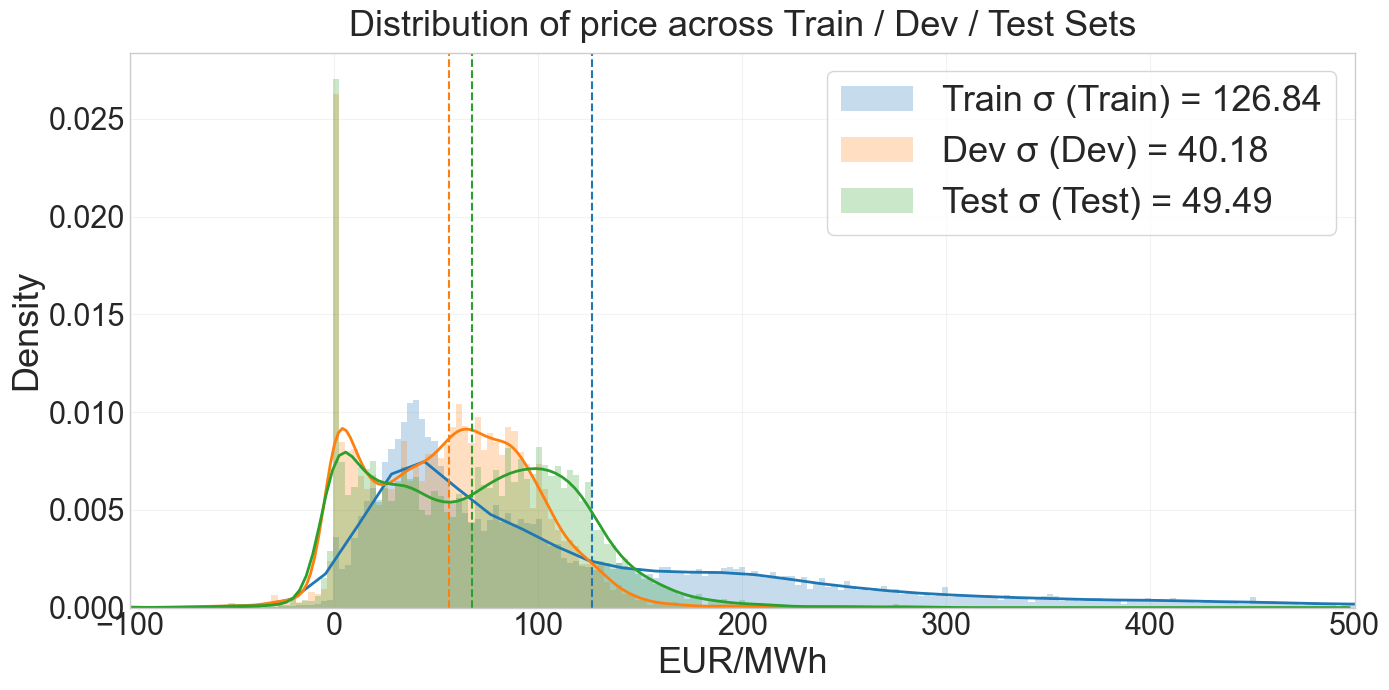

In [9]:

# ===========================
# Better color palette
# ===========================
colors = {
    "Train":  "#1f77b4",   # blue
    "Dev":    "#ff7f0e",   # orange
    "Test":   "#2ca02c"    # green
}

plt.figure(figsize=(14, 7))

# ===========================
# Histograms (transparent, same bins)
# ===========================
bins = np.linspace(-100, 500, 200)

for (name, df) in zip(["Train", "Dev", "Test"],
                      [train_df_FR, dev_df_FR, test_df_FR]):

    plt.hist(df["EUR/MWh"], bins=bins, density=True,
             alpha=0.25, label=f"{name} σ ({name}) = {df['EUR/MWh'].std():.2f}",
             color=colors[name], edgecolor="none")
    
    # KDE curve
    sns.kdeplot(df["EUR/MWh"], color=colors[name], linewidth=2)

    # Mean line
    mean_val = df["EUR/MWh"].mean()
    plt.axvline(mean_val, color=colors[name], linestyle="--", linewidth=1.5)

# ===========================
# Formatting
# ===========================
plt.title("Distribution of price across Train / Dev / Test Sets",
          fontsize=26, pad=12)
plt.xlabel("EUR/MWh", fontsize=26)
plt.ylabel("Density", fontsize=26)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xlim(-100, 500)
plt.grid(alpha=0.25)
plt.legend(fontsize=26, frameon=True)

plt.tight_layout()
plt.show()


In [10]:
#Random shuffling of months 
def split_all_data_by_months(all_data, months_split):
    """
    Split a merged DataFrame into train/dev/test using month lists
    produced by a month-based split.
    """

    # Convert to pandas Period for comparison
    month_periods = all_data['date'].dt.to_period("M")

    # Extract month groups
    train_m = months_split["train"]
    dev_m   = months_split["dev"]
    test_m  = months_split["test"]

    # Masks
    mask_train = month_periods.isin(train_m)
    mask_dev   = month_periods.isin(dev_m)
    mask_test  = month_periods.isin(test_m)

    # Split dataframe
    train_df = all_data[mask_train].copy()
    dev_df   = all_data[mask_dev].copy()
    test_df  = all_data[mask_test].copy()

    return train_df, dev_df, test_df


In [11]:

train_months = [
    '2023-10','2022-02','2021-04','2021-11','2023-01','2022-11','2024-10','2023-12',
    '2022-07','2022-03','2024-07','2025-01','2023-06','2021-03','2020-02','2021-10',
    '2021-07','2020-05','2021-12','2025-02','2025-09','2024-06','2025-07','2020-03',
    '2019-11','2022-01','2024-01','2019-12','2023-02','2025-08','2025-06','2021-06',
    '2024-08','2022-06','2023-04','2021-09','2024-04','2021-01','2020-07','2022-05',
    '2023-05','2021-02','2024-02'
]

dev_months = [
    '2020-01','2022-08','2022-04','2020-08','2024-09','2025-05','2024-12','2020-04',
    '2022-12','2024-11','2020-09','2024-05','2023-03','2023-08'
]

test_months = [
    '2021-08','2021-05','2022-09','2019-10','2023-09','2023-11','2023-07','2020-10',
    '2024-03','2020-12','2020-11','2025-04','2022-10','2025-03','2020-06'
]

splits = {
    'train': pd.PeriodIndex(train_months, freq='M'),
    'dev':   pd.PeriodIndex(dev_months,   freq='M'),
    'test':  pd.PeriodIndex(test_months,  freq='M')
}


In [12]:
train_df, dev_df, test_df = split_all_data_by_months(all_data, splits)


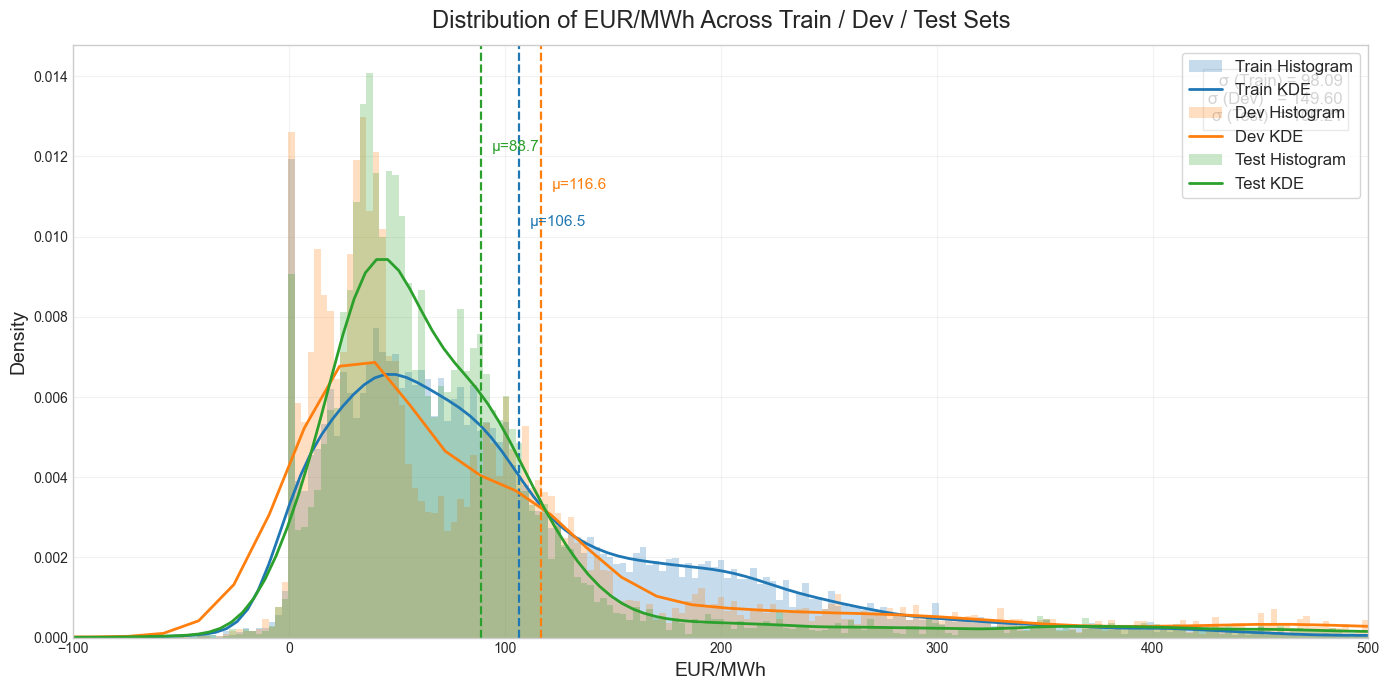

In [13]:


# ======================================
# Professional color palette
# ======================================
colors = {
    "Train": "#1f77b4",   # blue
    "Dev":   "#ff7f0e",   # orange
    "Test":  "#2ca02c"    # green
}

plt.figure(figsize=(14, 7))

# Consistent binning
bins = np.linspace(-100, 500, 200)

# ======================================
# Histograms + KDE curves + Mean lines
# ======================================
for (name, df) in zip(["Train", "Dev", "Test"],
                      [train_df, dev_df, test_df]):

    # Histogram
    plt.hist(df["EUR/MWh"], bins=bins, density=True,
             alpha=0.25, label=f"{name} Histogram",
             color=colors[name], edgecolor='none')

    # KDE curve
    sns.kdeplot(df["EUR/MWh"], color=colors[name], linewidth=2,
                label=f"{name} KDE")

    # Mean line
    μ = df["EUR/MWh"].mean()
    plt.axvline(μ, color=colors[name], linestyle="--", linewidth=1.6)
    plt.text(μ + 5, plt.ylim()[1]*0.82,
             f"μ={μ:.1f}", color=colors[name], fontsize=11)

# ======================================
# Standard deviation box (non-overlapping)
# ======================================
text = (
    f"σ (Train) = {train_df['EUR/MWh'].std():.2f}\n"
    f"σ (Dev)   = {dev_df['EUR/MWh'].std():.2f}\n"
    f"σ (Test)  = {test_df['EUR/MWh'].std():.2f}"
)

plt.text(0.98, 0.95, text, ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=12,
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray'))

# ======================================
# Styling and formatting
# ======================================
plt.title("Distribution of EUR/MWh Across Train / Dev / Test Sets",
          fontsize=17, pad=12)
plt.xlabel("EUR/MWh", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xlim(-100, 500)

plt.grid(alpha=0.25)
plt.legend(fontsize=12, frameon=True)

plt.tight_layout()
plt.show()
